In [1]:
import pandas as pd
from pathlib import Path
SRC = Path("/home/100/mj8805/scr_mk27/")
spectra = pd.read_parquet(SRC / "bulge-ages-and-orbits/data/merged_with_ages_raw.parquet")

In [2]:
import matplotlib.pyplot as plt
from mw_plot import MWSkyMap

In [10]:
import matplotlib
%matplotlib inline

In [3]:
import numpy as np

In [4]:
SELECTED_COLS = ['fe_h', 'age_Dnu']
spectra = spectra[np.abs(spectra['fe_h']) < 1.5]
spectra = spectra[np.abs(spectra['age_Dnu']) < 20.0]

In [6]:
import astropy.units as u

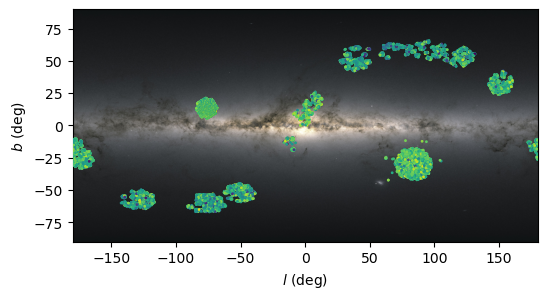

In [14]:
mw1.scatter(spectra['ra'].values*u.degree, spectra['dec'].values*u.degree, c=spectra['fe_h'], cmap='viridis', s=1)
plt.show()

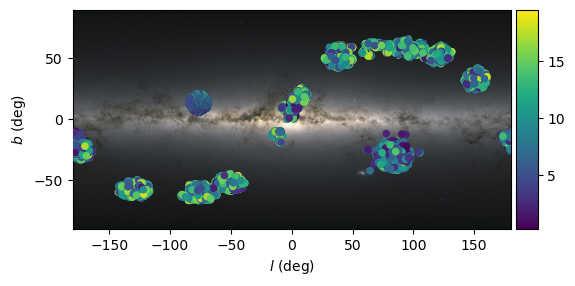

In [37]:
# ---- Plot scatter points with colorbar for age_Dnu ----
# This uses mw_scatter to enable colorbars in MWSkyMap

# To use mw_scatter with a colorbar, pass [values, label] as c,
# and do NOT pass cmap in kwargs (it is set via mw1.cmap)

mw1 = MWSkyMap()
mw1.cmap = 'viridis'
mw1.cbar_flag = True
mw1.mw_scatter(
    spectra['ra'].values * u.degree,
    spectra['dec'].values * u.degree,
    c = spectra['age_Dnu']
)
plt.show()

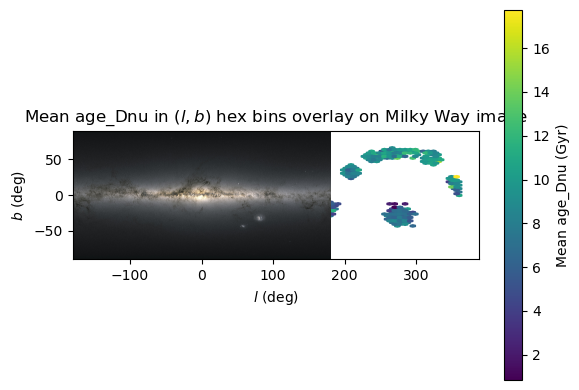

In [ ]:
# ---- Overlay hexbin of mean age_Dnu on Milky Way image from mw_plot ----

from mw_plot import MWSkyMap
import astropy.units as u
from astropy.coordinates import SkyCoord

# Make sure we have l, b columns in spectra DataFrame
if not all(x in spectra.columns for x in ['l', 'b']):
    coords = SkyCoord(ra=spectra['ra'].values * u.degree, dec=spectra['dec'].values * u.degree, frame='icrs')
    spectra['l'] = coords.galactic.l.deg
    spectra['b'] = coords.galactic.b.deg

# Create a sky map background using mw_plot
mw = MWSkyMap()  # 'MW_bg_annotate' gives annotated galaxy image
mw.initialize_mwplot()
# Overlay hexbin (mean age_Dnu) in galactic coordinates on top of galaxy image
hb = mw.ax.hexbin(
    spectra['l'],
    spectra['b'],
    C=spectra['age_Dnu'],
    gridsize=50,
    reduce_C_function=np.mean,
    cmap='viridis',
    mincnt=1,zor
)
cb = mw.fig.colorbar(hb, ax=mw.ax, label='Mean age_Dnu (Gyr)')
mw.ax.set_title('Mean age_Dnu in $(l, b)$ hex bins overlay on Milky Way image')

mw.show()

In [47]:
mw.__dict__

{'_gh_imgbase_url': 'https://github.com/henrysky/milkyway_plot/raw/master/mw_plot/',
 '_in_jupyter': True,
 '_MW_IMAGES': {'MW_bg_unannotate': MWImage(filename='MW_bg_unannotate.jpg', citation='NASA/JPL-Caltech/R. Hurt (SSC/Caltech)'),
  'MW_bg_annotate': MWImage(filename='MW_bg_annotate.jpg', citation='NASA/JPL-Caltech/R. Hurt (SSC/Caltech)'),
  'MW_edgeon_edr3_unannotate': MWImage(filename='MW_edgeon_edr3_unannotate.jpg', citation='ESA/Gaia/DPAC'),
  'MW_fermi_gamma': MWImage(filename='MW_fermi_gamma.jpg', citation='NASA/DOE/Fermi LAT Collaboration'),
  'MW_2mass': MWImage(filename='MW_2mass.jpg', citation='2MASS/IPAC/Caltech/University of Massachusetts'),
  'MW_farinfrared': MWImage(filename='MW_farinfrared.jpg', citation='WISE/NASA/JPL-Caltech/UCLA & IRAS/NASA')},
 'projection': 'equirectangular',
 'wavlength': 'optical',
 'center': <Quantity [0., 0.] deg>,
 'radius': <Quantity [180.,  90.] deg>,
 'grayscale': False,
 'figsize': (6, 4),
 '_built': False,
 '_opposite_color': 'white'